# LaBraM

论文链接：[LaBraM: Large Brain Model](https://openreview.net/forum?id=QzTpTRVtrP)

## Methods

LaBraM 是把连续 EEG 转成类似语言模型中的离散 token，再做 masked token prediction。给定 EEG 样本
$$X\in\mathbb{R}^{C\times T},$$
先按通道和时间切成 channel-time patches：
$$x_{c,p}\in\mathbb{R}^{L},\quad c=1,\ldots,C,\;p=1,\ldots,P.$$
每个 patch 经过 temporal encoder 得到表征，并加入空间/时间位置 embedding，使模型知道 token 来自哪个电极和哪个时间窗口。

第一阶段训练 neural tokenizer。LaBraM 定义离散 codebook
$$\mathcal{V}=\{v_k\}_{k=1}^{K},\quad v_k\in\mathbb{R}^{D},$$
并把 patch 表征量化为最近的 code：
$$q(c,p)=\arg\min_k\|E_\phi(x_{c,p})-v_k\|_2^2.$$
与直接重建原始 EEG 不同，LaBraM 让 tokenizer 预测 Fourier 频谱的幅值和相位：
$$\mathcal{L}_{spec}=
\|\hat{A}_{c,p}-A_{c,p}\|_2^2+
\|\hat{\varphi}_{c,p}-\varphi_{c,p}\|_2^2.$$
这样得到的离散 neural token 更偏向稳定的频域语义，而不是低信噪比的瞬时波形细节。

第二阶段固定 tokenizer，训练 LaBraM Transformer 做 masked EEG modeling。随机遮挡 patch 集合 $\mathcal{M}$，模型根据可见上下文预测被遮挡位置的离散 neural token：
$$\mathcal{L}_{M}=
-\sum_{(c,p)\in\mathcal{M}}
\log P_{\theta}\left(q(c,p)\mid X_{\setminus\mathcal{M}}\right).$$
这相当于 EEG 版 BERT：tokenizer 提供 EEG vocabulary，Transformer 学习跨通道、跨时间的上下文关系。

下游任务中，取 Transformer 输出表征做 pooling，再接分类头：
$$h=\mathrm{pool}(F_\theta(X)),\qquad
\hat{y}=\mathrm{softmax}(Wh+b).$$

## Tiny 版

原论文均使用大规模 EEG 语料和较大的 Transformer 进行预训练。为了在普通 CPU 环境中直接运行，下面实现的是论文的轻量版预训练：先在 `data/go2_eeg_preprocessed.npz` 上构造自监督预训练任务，再用同一个骨干网络微调三分类头。

In [1]:
from pathlib import Path
import math
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def find_project_root(start=Path.cwd()):
    start = Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "data" / "go2_eeg_preprocessed.npz").exists():
            return path
    raise FileNotFoundError("Cannot find data/go2_eeg_preprocessed.npz from current path.")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "go2_eeg_preprocessed.npz"
# print("project root:", PROJECT_ROOT)


device: cuda


In [2]:
data = np.load(DATA_PATH, allow_pickle=True)
X_train = data["X_train"].astype("float32")
X_test = data["X_test"].astype("float32")
y_train = data["y_train"].astype("int64")
y_test = data["y_test"].astype("int64")
label_classes = data["label_classes"].astype(str).tolist()
sfreq = int(data["target_sfreq"])

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("classes:", dict(enumerate(label_classes)), "sfreq:", sfreq)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=32,
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=64,
    shuffle=False,
)

X_train: (141, 8, 1248) X_test: (36, 8, 1248)
classes: {0: 'L', 1: 'R', 2: 'S'} sfreq: 250


In [3]:
def patchify(x, patch_len=64):
    """Return channel-time patches with shape (B, C, P, patch_len)."""
    b, c, t = x.shape
    n_patches = t // patch_len
    x = x[..., : n_patches * patch_len]
    return x.reshape(b, c, n_patches, patch_len)


def make_mask(batch, channels, patches, mask_ratio=0.35, contiguous=False):
    mask = torch.zeros(batch, channels, patches, dtype=torch.bool)
    if contiguous:
        span_t = max(1, int(round(patches * mask_ratio)))
        span_c = max(1, int(round(channels * 0.4)))
        for i in range(batch):
            t0 = torch.randint(0, patches - span_t + 1, (1,)).item()
            c0 = torch.randint(0, channels - span_c + 1, (1,)).item()
            mask[i, c0 : c0 + span_c, t0 : t0 + span_t] = True
    else:
        mask = torch.rand(batch, channels, patches) < mask_ratio
        empty = ~mask.flatten(1).any(dim=1)
        if empty.any():
            mask[empty, 0, 0] = True
    return mask


def run_classifier(model, train_loader, test_loader, epochs=25, lr=1e-3):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    history = {"loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        pred_all, true_all = [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())
            pred_all.extend(logits.argmax(1).detach().cpu().numpy())
            true_all.extend(yb.cpu().numpy())

        test_pred, test_true, _ = predict(model, test_loader)
        history["loss"].append(float(np.mean(losses)))
        history["train_acc"].append(accuracy_score(true_all, pred_all))
        history["test_acc"].append(accuracy_score(test_true, test_pred))
        if epoch in {1, epochs} or epoch % 5 == 0:
            print(
                f"epoch {epoch:02d} | loss={history['loss'][-1]:.4f} "
                f"| train_acc={history['train_acc'][-1]:.3f} | test_acc={history['test_acc'][-1]:.3f}"
            )
    return history


@torch.no_grad()
def predict(model, loader):
    model.eval()
    pred_all, true_all, prob_all = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        prob = logits.softmax(dim=1).cpu().numpy()
        prob_all.append(prob)
        pred_all.extend(prob.argmax(axis=1))
        true_all.extend(yb.numpy())
    return np.array(pred_all), np.array(true_all), np.vstack(prob_all)


def plot_results(history, y_true, y_pred, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["train_acc"], label="train")
    axes[0].plot(history["test_acc"], label="test")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(title)
    axes[0].legend()
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=axes[1], cmap="Blues", colorbar=False)
    axes[1].set_title("Test confusion matrix")
    plt.tight_layout()
    plt.show()

用 `MiniBatchKMeans` 对每个 EEG patch 的 FFT 幅值聚类，模拟 LaBraM 的离散 neural codebook；预训练阶段遮挡 patch 并预测其 code id，微调阶段对 Transformer 的全局平均表征接三分类头。

In [4]:
class TinyLaBraMEncoder(nn.Module):
    def __init__(self, channels, n_patches, patch_len=64, d_model=64, depth=2, heads=4):
        super().__init__()
        self.channels = channels
        self.n_patches = n_patches
        self.patch_len = patch_len
        self.patch_proj = nn.Linear(patch_len, d_model)
        self.channel_embed = nn.Parameter(torch.randn(channels, d_model) * 0.02)
        self.time_embed = nn.Parameter(torch.randn(n_patches, d_model) * 0.02)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, 1, d_model))
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=heads, dim_feedforward=128, dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(d_model)

    def forward_tokens(self, x, mask=None):
        patches = patchify(x, self.patch_len)
        z = self.patch_proj(patches)
        if mask is not None:
            z = torch.where(mask[..., None], self.mask_token.to(z.dtype), z)
        z = z + self.channel_embed[None, :, None, :] + self.time_embed[None, None, :, :]
        b, c, p, d = z.shape
        z = z.reshape(b, c * p, d)
        return self.norm(self.transformer(z)).reshape(b, c, p, d)

    def forward(self, x):
        z = self.forward_tokens(x)
        return z.mean(dim=(1, 2))


class LaBraMPretrainer(nn.Module):
    def __init__(self, encoder, n_codes):
        super().__init__()
        self.encoder = encoder
        self.token_head = nn.Linear(64, n_codes)

    def forward(self, x, mask):
        z = self.encoder.forward_tokens(x, mask=mask)
        return self.token_head(z)


class LaBraMClassifier(nn.Module):
    def __init__(self, encoder, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(nn.LayerNorm(64), nn.Linear(64, n_classes))

    def forward(self, x):
        return self.head(self.encoder(x))

neural codebook size: 32 patches used: 21432
pretrain epoch 01 | masked-token loss=3.4707
pretrain epoch 02 | masked-token loss=3.2905
pretrain epoch 03 | masked-token loss=3.2563
pretrain epoch 04 | masked-token loss=3.2242
pretrain epoch 05 | masked-token loss=3.1852
epoch 01 | loss=1.1657 | train_acc=0.270 | test_acc=0.278
epoch 05 | loss=1.0515 | train_acc=0.454 | test_acc=0.194
epoch 10 | loss=0.9538 | train_acc=0.504 | test_acc=0.222
epoch 15 | loss=0.7901 | train_acc=0.660 | test_acc=0.250
epoch 20 | loss=0.5111 | train_acc=0.830 | test_acc=0.194
epoch 25 | loss=0.3170 | train_acc=0.887 | test_acc=0.194
              precision    recall  f1-score   support

           L       0.00      0.00      0.00        12
           R       0.20      0.25      0.22        12
           S       0.27      0.33      0.30        12

    accuracy                           0.19        36
   macro avg       0.16      0.19      0.17        36
weighted avg       0.16      0.19      0.17        36



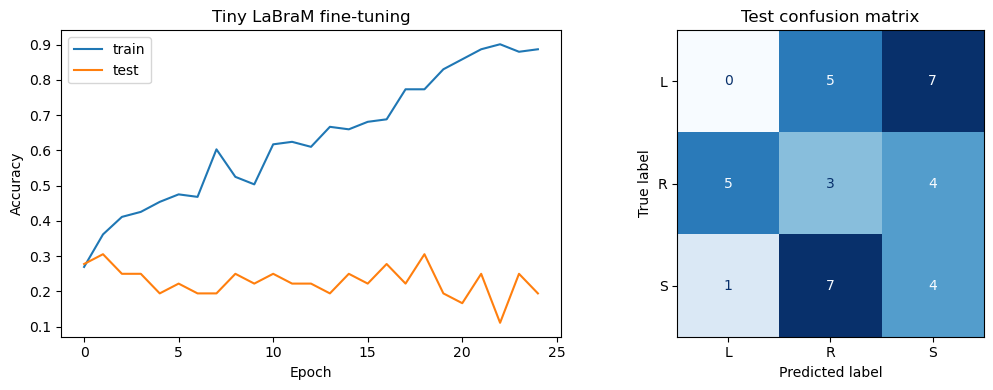

In [5]:
patch_len = 64
channels = X_train.shape[1]
n_patches = X_train.shape[2] // patch_len
n_classes = len(label_classes)
n_codes = 32

train_patches = patchify(torch.tensor(X_train), patch_len).numpy().reshape(-1, patch_len)
fft_features = np.abs(np.fft.rfft(train_patches, axis=1))

def fit_numpy_kmeans(features, n_clusters=32, n_iter=25, seed=42):
    rng = np.random.default_rng(seed)
    features = features.astype("float32")
    centers = features[rng.choice(len(features), n_clusters, replace=False)].copy()
    for _ in range(n_iter):
        dist = ((features[:, None, :] - centers[None, :, :]) ** 2).sum(axis=-1)
        labels = dist.argmin(axis=1)
        for k in range(n_clusters):
            if np.any(labels == k):
                centers[k] = features[labels == k].mean(axis=0)
    return centers

def predict_numpy_kmeans(features, centers):
    features = features.astype("float32")
    dist = ((features[:, None, :] - centers[None, :, :]) ** 2).sum(axis=-1)
    return dist.argmin(axis=1)

centers = fit_numpy_kmeans(fft_features, n_clusters=n_codes, seed=SEED)
patch_codes = predict_numpy_kmeans(fft_features, centers)
print("neural codebook size:", n_codes, "patches used:", len(patch_codes))

def encode_codes(x_np):
    patches = patchify(torch.tensor(x_np), patch_len).numpy().reshape(-1, patch_len)
    feats = np.abs(np.fft.rfft(patches, axis=1))
    codes = predict_numpy_kmeans(feats, centers)
    return torch.tensor(codes.reshape(len(x_np), channels, n_patches), dtype=torch.long)

train_codes = encode_codes(X_train)

encoder = TinyLaBraMEncoder(channels, n_patches, patch_len=patch_len)
pretrainer = LaBraMPretrainer(encoder, n_codes).to(device)
opt = torch.optim.AdamW(pretrainer.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, 6):
    pretrainer.train()
    losses = []
    for batch_idx, (xb, _) in enumerate(train_loader):
        xb = xb.to(device)
        code = train_codes[batch_idx * train_loader.batch_size : batch_idx * train_loader.batch_size + len(xb)].to(device)
        mask = make_mask(len(xb), channels, n_patches, mask_ratio=0.4).to(device)
        logits = pretrainer(xb, mask)
        target = code.clone()
        target[~mask] = -100
        loss = F.cross_entropy(logits.reshape(-1, n_codes), target.reshape(-1), ignore_index=-100)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    print(f"pretrain epoch {epoch:02d} | masked-token loss={np.mean(losses):.4f}")

classifier = LaBraMClassifier(encoder, n_classes)
history = run_classifier(classifier, train_loader, test_loader, epochs=25, lr=8e-4)
y_pred, y_true, y_prob = predict(classifier, test_loader)
print(classification_report(y_true, y_pred, target_names=label_classes, zero_division=0))
plot_results(history, y_true, y_pred, label_classes, "Tiny LaBraM fine-tuning")

## GPU 版

下载官方仓库到 `tutorials/Foundation Model/official_code/LaBraM`，权重位于 `checkpoints/labram-base.pth`，tokenizer 权重位于 `checkpoints/vqnsp.pth`。下面的单元默认不运行；在安装 `timm einops` 且有 CUDA GPU 后，把 `RUN_OFFICIAL_GPU=True` 即可用论文的 LaBraM 模型在 Go2 EEG 数据上微调。

In [6]:
from pathlib import Path
import sys

RUN_OFFICIAL_GPU = True  # 是否运行官方大模型微调
OFFICIAL_ROOT = PROJECT_ROOT / "tutorials" / "Foundation Model" / "official_code"
print("official code root:", OFFICIAL_ROOT)
print("CUDA available:", torch.cuda.is_available())

official code root: C:\Users\zxzhang\Desktop\智能脑机接口\实验\tutorials\Foundation Model\official_code
CUDA available: True


loaded official LaBraM: 195 compatible tensors; 4 missing; 0 unexpected; 29 skipped
epoch 01 | loss=1.0989 | train_acc=0.255 | test_acc=0.333
epoch 05 | loss=1.0977 | train_acc=0.567 | test_acc=0.361
epoch 10 | loss=1.0786 | train_acc=0.851 | test_acc=0.278
epoch 15 | loss=1.0197 | train_acc=0.993 | test_acc=0.306
epoch 20 | loss=0.9573 | train_acc=1.000 | test_acc=0.306
epoch 25 | loss=0.9021 | train_acc=1.000 | test_acc=0.222
              precision    recall  f1-score   support

           L       0.12      0.08      0.10        12
           R       0.26      0.42      0.32        12
           S       0.22      0.17      0.19        12

    accuracy                           0.22        36
   macro avg       0.20      0.22      0.20        36
weighted avg       0.20      0.22      0.20        36



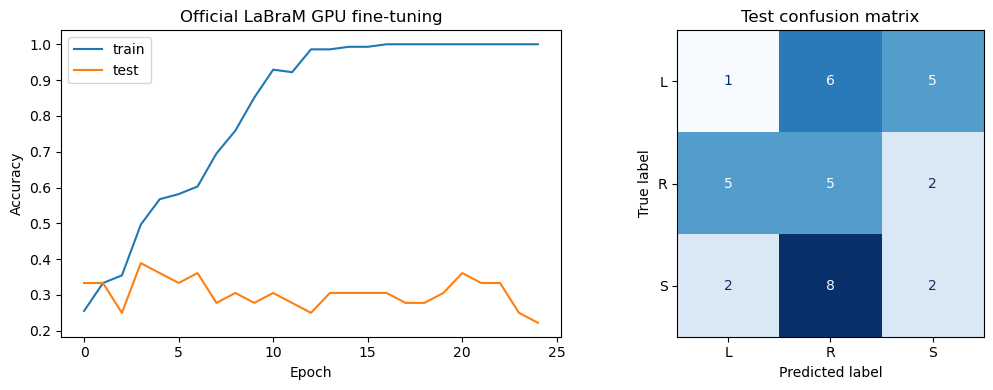

In [7]:

if RUN_OFFICIAL_GPU:
    assert torch.cuda.is_available(), "官方 GPU 微调需要 CUDA。当前环境没有检测到 GPU。"
    labram_root = OFFICIAL_ROOT / "LaBraM"
    ckpt_path = labram_root / "checkpoints" / "labram-base.pth"
    assert ckpt_path.exists(), f"Missing checkpoint: {ckpt_path}"
    sys.path.insert(0, str(labram_root))
    try:
        from modeling_finetune import labram_base_patch200_200
    except ImportError as exc:
        raise ImportError("请先安装官方依赖：pip install timm einops") from exc

    class OfficialLaBraMGo2(nn.Module):
        def __init__(self, n_classes):
            super().__init__()
            # 官方 modeling_finetune.py 的 Block 会执行 init_values > 0；必须显式传入数值，避免默认 None 触发 TypeError。
            self.backbone = labram_base_patch200_200(num_classes=n_classes, init_values=0.0)
            # input_chans 包含 cls 位置 0 和 8 个示例 EEG 通道的位置编码索引。
            # 如果不传，官方模型会默认展开 128 个通道的位置编码，导致 65 vs 1025 的 token 长度错误。
            self.register_buffer("input_chans", torch.arange(0, 9, dtype=torch.long))
            raw_state = torch.load(ckpt_path, map_location="cpu")
            state = raw_state.get("model", raw_state.get("state_dict", raw_state))
            # labram-base.pth 是自监督预训练 checkpoint，backbone 参数通常带 student. 前缀。
            if any(k.startswith("student.") for k in state):
                state = {k.replace("student.", "", 1): v for k, v in state.items() if k.startswith("student.")}

            # 只加载名称存在且 shape 一致的参数；分类头和预训练专用 token 会自动跳过。
            target_state = self.backbone.state_dict()
            compatible_state = {
                k: v for k, v in state.items()
                if k in target_state and tuple(v.shape) == tuple(target_state[k].shape)
            }
            skipped = sorted(set(state) - set(compatible_state))
            missing, unexpected = self.backbone.load_state_dict(compatible_state, strict=False)
            print(
                "loaded official LaBraM:",
                len(compatible_state), "compatible tensors;",
                len(missing), "missing;",
                len(unexpected), "unexpected;",
                len(skipped), "skipped"
            )

        def forward(self, x):
            # 官方 LaBraM base 默认 patch=200、窗口=1600；Go2 demo 为 1248 点，这里线性插值到 1600。
            x = F.interpolate(x, size=1600, mode="linear", align_corners=False)
            x = x.reshape(x.shape[0], x.shape[1], 8, 200)
            return self.backbone(x, input_chans=self.input_chans)

    official_model = OfficialLaBraMGo2(len(label_classes))
    official_history = run_classifier(official_model, train_loader, test_loader, epochs=25, lr=1e-5)
    official_pred, official_true, _ = predict(official_model, test_loader)
    print(classification_report(official_true, official_pred, target_names=label_classes, zero_division=0))
    plot_results(official_history, official_true, official_pred, label_classes, "Official LaBraM GPU fine-tuning")
else:
    print("官方 LaBraM GPU 微调已跳过。确认 CUDA 和依赖可用后，将 RUN_OFFICIAL_GPU 改为 True。")

## 结果分析

In [8]:
final_acc = accuracy_score(y_true, y_pred)
chance = 1 / len(label_classes)
print(f"Final test accuracy: {final_acc:.3f} | chance level: {chance:.3f}")

class_counts = {label: int((y_true == i).sum()) for i, label in enumerate(label_classes)}
print("Test class counts:", class_counts)

if final_acc <= chance + 0.05:
    print("分析：当前小样本 demo 的结果接近随机水平，说明预训练轮数、数据规模或标签信噪比仍不足。")
elif history["train_acc"][-1] - history["test_acc"][-1] > 0.25:
    print("分析：训练集明显高于测试集，存在过拟合。可以减少模型宽度、增加正则化或使用更多被试/会话。")
else:
    print("分析：测试准确率高于随机水平，说明预训练得到的时空表征对 L/R/S 三类解码有一定帮助。")

Final test accuracy: 0.194 | chance level: 0.333
Test class counts: {'L': 12, 'R': 12, 'S': 12}
分析：当前小样本 demo 的结果接近随机水平，说明预训练轮数、数据规模或标签信噪比仍不足。
